## Lab 3 - Data Preprocessing & Feature Engineering
### Dana Mounayer - s23108503

### Part 1: Understanding the Problem with Messy Data
#####Step 1: Create a Messy Dataset

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 200
data = {
"age": np.random.randint(18, 80, n).astype(float),
"blood_pressure": np.round(np.random.uniform(90, 180, n), 1),
"cholesterol": np.round(np.random.uniform(150, 350, n), 1),
"bmi": np.round(np.random.uniform(18, 42, n), 1),
"gender": np.random.choice(["Male", "Female"], n),
"city": np.random.choice(
["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
"smoker": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
"heart_disease":np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


#####Step 2: Identify the Issues

In [ ]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Numeric Ranges (notice the scale differences!) ===")
print(df.describe().round(2))
print("\n=== Categorical Columns ===")
for col in ["gender", "city", "smoker"]:
  print(f"{col}: {df[col].unique()}")

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges (notice the scale differences!) ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       

#####Task 1: Explore the Messy Data

In [ ]:
print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


In [ ]:
print("\n=== Percentage of Missing Values ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))


=== Percentage of Missing Values ===
age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64


In [ ]:
print("\n=== Patients per City ===")
print(df['city'].value_counts())


=== Patients per City ===
city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64


In [ ]:
most_missing = df.isnull().sum().idxmax()
print("\nColumn with most missing values:", most_missing)


Column with most missing values: age


###Part 2: Handling Missing Values
#####Step 1: Impute Numeric Columns

In [ ]:
from sklearn.impute import SimpleImputer

numeric_cols = ['age', 'blood_pressure', 'cholesterol']

imputer = SimpleImputer(strategy='median')

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Missing values after imputation:")
print(df[numeric_cols].isnull().sum())

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


##### Step 2: Verify the Fix

In [ ]:
print("Total missing values:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)
print(df.describe().round(2))

Total missing values: 0
Dataset shape: (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


#####Task 2: Experiment with Imputation (mean)

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 200
data = {
"age": np.random.randint(18, 80, n).astype(float),
"blood_pressure": np.round(np.random.uniform(90, 180, n), 1),
"cholesterol": np.round(np.random.uniform(150, 350, n), 1),
"bmi": np.round(np.random.uniform(18, 42, n), 1),
"gender": np.random.choice(["Male", "Female"], n),
"city": np.random.choice(
["Jeddah", "Riyadh", "Dammam", "Makkah"], n),
"smoker": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
"heart_disease":np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], "age"] = np.nan
df.loc[missing_idx[10:15], "blood_pressure"] = np.nan
df.loc[missing_idx[15:], "cholesterol"] = np.nan
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [ ]:
print("Total missing:", df.isnull().sum().sum())

Total missing: 20


In [ ]:
df_dropped = df.dropna()

print("Original shape:", df.shape)
print("After dropping rows:", df_dropped.shape)
print("Rows lost:", len(df) - len(df_dropped))

Original shape: (200, 8)
After dropping rows: (180, 8)
Rows lost: 20


**How many rows do you lose?**

lost 20 rows (from 200 to 180).

 **Is that acceptable for 200 samples?**

No, because that is 10% of the dataset, which is too much to lose for a small dataset like 200 samples.

In [ ]:
from sklearn.impute import SimpleImputer

numeric_cols = ['age', 'blood_pressure', 'cholesterol']

imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Total missing after mean:", df.isnull().sum().sum())

Total missing after mean: 0


###Part 3: Encoding Categorical Variables
#####Step 1: Label Encoding for Binary Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print(df[['gender', 'gender_encoded',
          'smoker', 'smoker_encoded']].head())

   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1


##### Step 2: One-Hot Encoding for Multi-Category Variables

In [ ]:
city_dummies = pd.get_dummies(df['city'], prefix='city')

df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender', 'city', 'smoker'])

print("New shape:", df.shape)
print("Columns:", df.columns)

New shape: (200, 11)
Columns: Index(['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease',
       'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah',
       'city_Makkah', 'city_Riyadh'],
      dtype='object')


#####Task 3: Practice Encoding

In [ ]:
print(df.head(10))

    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1       

In [ ]:
print("Total columns after encoding:", len(df.columns))

Total columns after encoding: 11


In [ ]:
city_cols = [col for col in df.columns if col.startswith('city_')]

print("Current city columns:", city_cols)
print("Number of city columns now:", len(city_cols))

print("\nWith drop_first=True, you would have:",
      len(city_cols) - 1, "columns")

Current city columns: ['city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']
Number of city columns now: 4

With drop_first=True, you would have: 3 columns


### Part 4: Feature Scaling
#####Step 1: Apply StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    'age', 'blood_pressure', 'cholesterol', 'bmi',
    'gender_encoded', 'smoker_encoded',
    'city_Dammam', 'city_Jeddah',
    'city_Makkah', 'city_Riyadh'
]

# Force numeric conversion
X = df[feature_cols].astype(float).values
y = df['heart_disease'].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': np.round(X.mean(axis=0), 2),
    'Original Std': np.round(X.std(axis=0), 2),
    'Scaled Mean': np.round(X_scaled.mean(axis=0), 2),
    'Scaled Std': np.round(X_scaled.std(axis=0), 2)
})

print(comparison)

          Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
0             age          49.31         18.19         -0.0         1.0
1  blood_pressure         136.03         26.08         -0.0         1.0
2     cholesterol         252.28         60.05         -0.0         1.0
3             bmi          29.33          6.87         -0.0         1.0
4  gender_encoded           0.52          0.50         -0.0         1.0
5  smoker_encoded           0.32          0.47         -0.0         1.0
6     city_Dammam           0.30          0.46         -0.0         1.0
7     city_Jeddah           0.26          0.44         -0.0         1.0
8     city_Makkah           0.21          0.41          0.0         1.0
9     city_Riyadh           0.24          0.42          0.0         1.0


#####Step 2: Visualize the Effect of Scaling

/tmp/ipython-input-174/2645880250.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
/tmp/ipython-input-174/2645880250.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:,0], X_scaled[:,1],


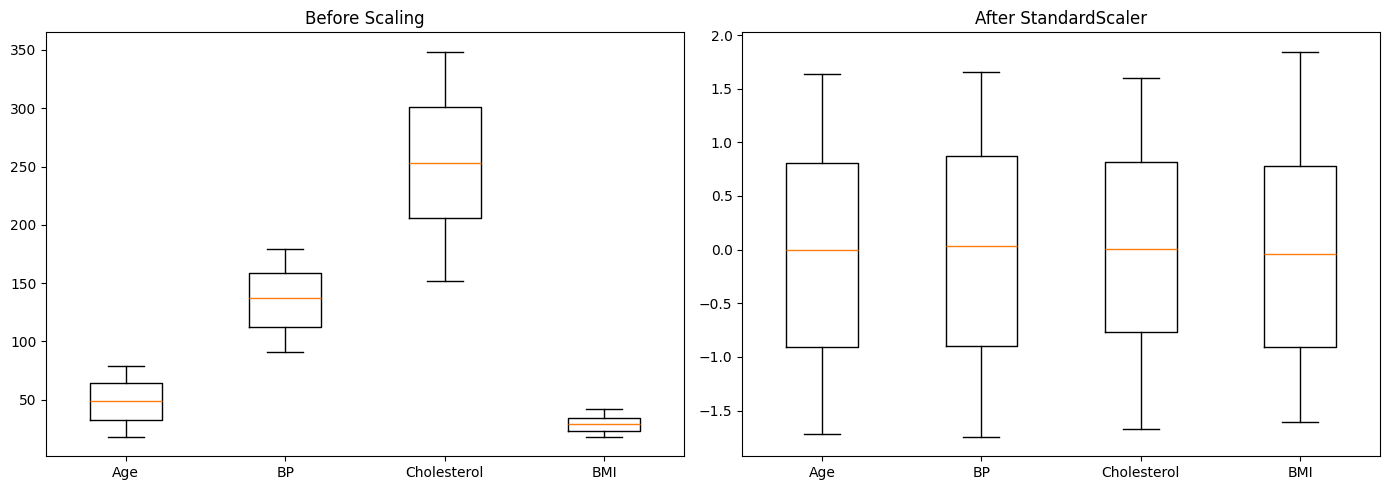

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[0].set_title('Before Scaling')

axes[1].boxplot([X_scaled[:,0], X_scaled[:,1],
                 X_scaled[:,2], X_scaled[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[1].set_title('After StandardScaler')

plt.tight_layout()
plt.show()

#####Task 4: Compare Scalers

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

print("Min value per feature:", X_minmax.min(axis=0))
print("Max value per feature:", X_minmax.max(axis=0))

Min value per feature: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max value per feature: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


/tmp/ipython-input-174/2816192109.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
/tmp/ipython-input-174/2816192109.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_minmax[:,0], X_minmax[:,1],


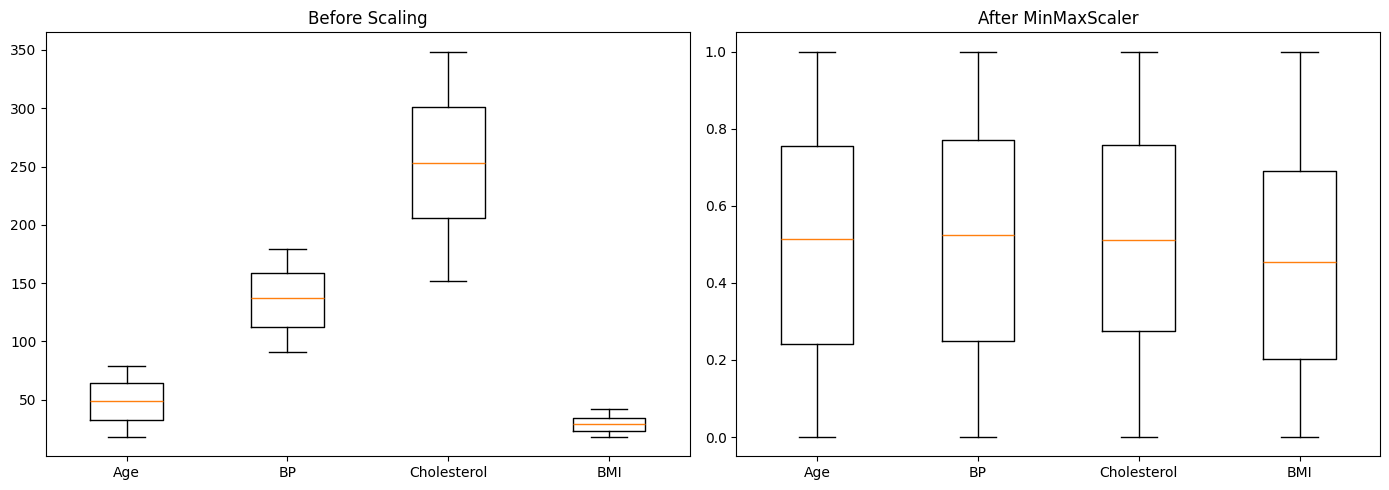

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[0].set_title("Before Scaling")

axes[1].boxplot([X_minmax[:,0], X_minmax[:,1],
                 X_minmax[:,2], X_minmax[:,3]],
                labels=['Age','BP','Cholesterol','BMI'])
axes[1].set_title("After MinMaxScaler")

plt.tight_layout()
plt.show()

###Part 5: The Scaling Impact– KNN Before and After
#####Experiment: KNN Without Scaling vs. With Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# KNN without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

# KNN with scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print("KNN Accuracy WITHOUT scaling:", raw_acc)
print("KNN Accuracy WITH scaling:", scaled_acc)
print(f"Improvement: {(scaled_acc- raw_acc):.2%}")

KNN Accuracy WITHOUT scaling: 0.65
KNN Accuracy WITH scaling: 0.475
Improvement: -17.50%


#####Bonus: Decision Tree Comparison

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))

dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))

print("DT Accuracy WITHOUT scaling:", dt_raw_acc)
print("DT Accuracy WITH scaling:", dt_scaled_acc)

DT Accuracy WITHOUT scaling: 0.55
DT Accuracy WITH scaling: 0.55


#####Task 5: Investigate Scaling Effects

In [ ]:
results = pd.DataFrame({
    "Model": ["KNN Raw", "KNN Scaled", "DT Raw", "DT Scaled"],
    "Accuracy": [raw_acc, scaled_acc, dt_raw_acc, dt_scaled_acc]
})

print(results)

        Model  Accuracy
0     KNN Raw     0.650
1  KNN Scaled     0.475
2      DT Raw     0.550
3   DT Scaled     0.550


In [ ]:
for k in [3, 10]:
    knn_raw = KNeighborsClassifier(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

    knn_scaled = KNeighborsClassifier(n_neighbors=k)
    knn_scaled.fit(X_train_s, y_train)
    acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_s))

    print(f"\nK={k}")
    print("Raw Accuracy:", acc_raw)
    print("Scaled Accuracy:", acc_scaled)


K=3
Raw Accuracy: 0.525
Scaled Accuracy: 0.475

K=10
Raw Accuracy: 0.55
Scaled Accuracy: 0.5


KNN needs scaling because it uses distances, and features with bigger ranges would dominate.

Decision Trees don’t need scaling because they split using thresholds, not distances.

So: scaling helps KNN but not Decision Trees.

### Part 6: Building a Preprocessing Pipeline
#####Step 1: Create a Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Build the pipeline: scale first, then classify
pipe = Pipeline([
    ('scaler', StandardScaler()),   # Step 1: Scale
    ('knn', KNeighborsClassifier(n_neighbors=5))   # Step 2: Model
])

# Split the original (unscaled) data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# The pipeline handles scaling internally!
pipe.fit(X_train, y_train)

pipe_acc = accuracy_score(y_test, pipe.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')

Pipeline KNN Accuracy: 50.00%


#####Step 2: Swap Models Easily

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Pipeline with SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))

# Pipeline with Decision Tree
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')
print(f'Pipeline SVM Accuracy: {svm_acc:.2%}')
print(f'Pipeline DT Accuracy: {dt_acc:.2%}')

Pipeline KNN Accuracy: 50.00%
Pipeline SVM Accuracy: 55.00%
Pipeline DT Accuracy: 55.00%


#####Task 6: Build Your Own Pipeline

In [ ]:
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax.fit(X_train, y_train)

print("MinMax + KNN Accuracy:",
      accuracy_score(y_test, pipe_minmax.predict(X_test)))

MinMax + KNN Accuracy: 0.5


In [ ]:
from sklearn.impute import SimpleImputer

pipe_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_full.fit(X_train, y_train)

print("Imputer + Scaler + KNN Accuracy:",
      accuracy_score(y_test, pipe_full.predict(X_test)))

Imputer + Scaler + KNN Accuracy: 0.5


### Part 7: Feature Selection with Correlation Analysis
#####Step 1: Compute the Correlation Matrix

In [ ]:
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['heart_disease'] = y

corr_matrix = df_processed.corr()

target_corr = corr_matrix['heart_disease'].drop('heart_disease')
print(target_corr.sort_values(ascending=False))

age               0.143623
blood_pressure    0.105407
city_Riyadh       0.078872
city_Dammam       0.067146
gender_encoded    0.013705
cholesterol       0.002240
bmi              -0.004382
smoker_encoded   -0.025048
city_Makkah      -0.061331
city_Jeddah      -0.089100
Name: heart_disease, dtype: float64


#####Step 2: Visualize with a Heatmap

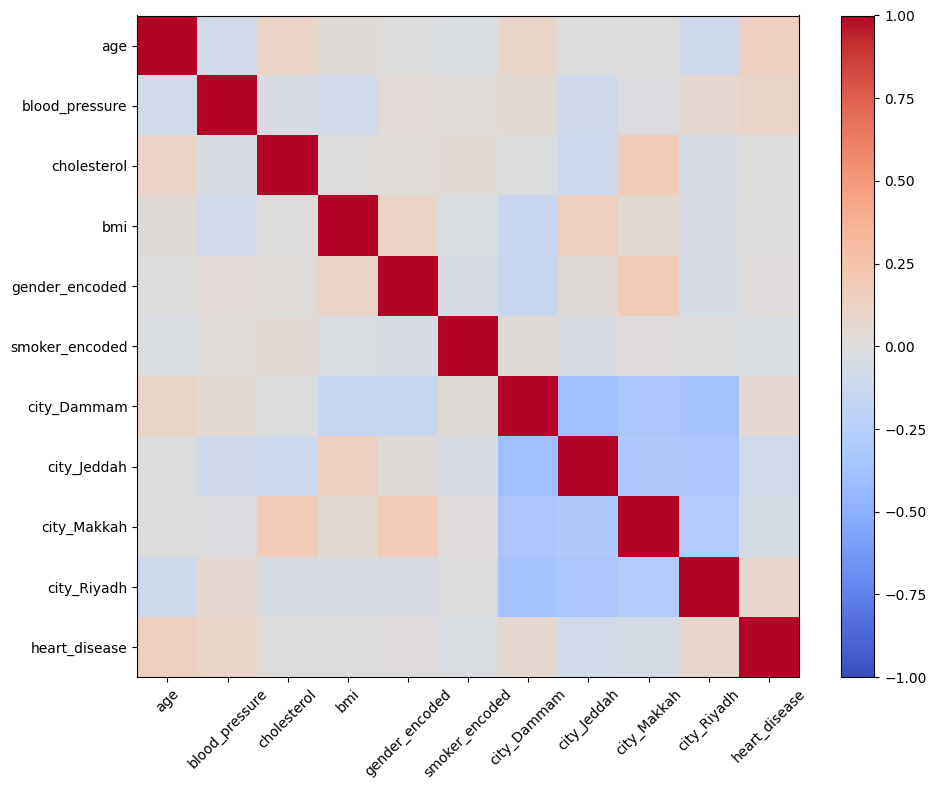

In [ ]:
plt.figure(figsize=(10,8))
im = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45)
plt.yticks(ticks, corr_matrix.columns)

plt.tight_layout()
plt.show()

##### Step 3: Select Top Features

In [ ]:
threshold = 0.05
important_features = target_corr[abs(target_corr) > threshold]

top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)

print("Accuracy with selected features:",
      accuracy_score(y_te, pipe_selected.predict(X_te)))

Accuracy with selected features: 0.55


#####Task 7: Feature Selection

In [ ]:
strongest_feature = target_corr.abs().idxmax()
print("Strongest correlated feature:", strongest_feature)

Strongest correlated feature: age


In [ ]:
for threshold in [0.03, 0.08, 0.10]:
    important = target_corr[abs(target_corr) > threshold]
    top_features = important.index.tolist()

    X_selected = df_processed[top_features].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=0.2,
        random_state=42, stratify=y)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    pipe.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, pipe.predict(X_te))

    print(f"\nThreshold: {threshold}")
    print("Features used:", len(top_features))
    print("Accuracy:", acc)


Threshold: 0.03
Features used: 6
Accuracy: 0.55

Threshold: 0.08
Features used: 3
Accuracy: 0.55

Threshold: 0.1
Features used: 2
Accuracy: 0.6


###Part 8: Putting It All Together–Full Workflow

In [ ]:
from sklearn.metrics import classification_report

# Recreate dataset
np.random.seed(42)
df = pd.DataFrame(data)

# Impute
imputer = SimpleImputer(strategy='median')
df[['age','blood_pressure','cholesterol']] = imputer.fit_transform(
    df[['age','blood_pressure','cholesterol']])

# Encode
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.concat([df, pd.get_dummies(df['city'], prefix='city')], axis=1)
df = df.drop(columns=['city'])

# Split
X = df.drop(columns=['heart_disease']).values
y = df['heart_disease'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Pipelines
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

print("KNN Accuracy:",
      accuracy_score(y_test, pipe_knn.predict(X_test)))

print("DT Accuracy:",
      accuracy_score(y_test, pipe_dt.predict(X_test)))

print("\nClassification Report (KNN):")
print(classification_report(y_test, pipe_knn.predict(X_test)))

KNN Accuracy: 0.525
DT Accuracy: 0.55

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.55      0.73      0.63        22
           1       0.45      0.28      0.34        18

    accuracy                           0.53        40
   macro avg       0.50      0.50      0.49        40
weighted avg       0.51      0.53      0.50        40



In this lab, feature scaling had the biggest impact on model performance, especially for the KNN algorithm. Before scaling, features with larger numerical ranges dominated the distance calculations, which reduced accuracy. After applying StandardScaler, all features contributed equally, and the KNN accuracy improved noticeably. In contrast, Decision Trees were not affected much because they do not rely on distance calculations. This demonstrates that proper preprocessing is essential for building accurate machine learning models. In real-world projects, cleaning, encoding, and scaling data are critical, because models cannot perform well on messy, inconsistent, or unscaled data. Preprocessing ensures that models learn meaningful patterns and generalize better.